# Analyzing and Plotting ProbCOPA Human Results

This notebook includes the code used to run statistical tests on the human results for ProbCOPA, as well as generate the plots presented in the paper. Before running this notebook, make sure you remove the canary strings from any files containing the actual human annotations, by running the following lines of code:

```
python scripts/remove_canary_strings.py --input-filepath "datasets/probcopa_CANARY.jsonl" --output-filepath "datasets/probcopa.jsonl"
python scripts/remove_canary_strings.py --input-filepath "results/probcopa_human_results_annotated_CANARY.jsonl" --output-filepath "results/probcopa_human_results_annotated.jsonl"
python scripts/remove_canary_strings.py --input-filepath "results/probcopa_random_sample_prompt_validation_round_human_results_CANARY.jsonl" --output-filepath "results/probcopa_random_sample_prompt_validation_round_human_results_cleaned.jsonl"
python scripts/remove_canary_strings.py --input-filepath "results/probcopa_random_sample_validation_round_human_results_CANARY.jsonl" --output-filepath "results/probcopa_random_sample_validation_round_human_results_cleaned.jsonl"
```

## Import libraries and read in data:

In [ ]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ast
from tqdm import tqdm


In [ ]:
# Read in human data:
human_data_path = "./datasets/probcopa.jsonl"
human_data = pd.read_json(human_data_path, lines=True)

## Annotate the human responses for things like differential entropy:

In [9]:
def attempt_digit_conversion(x):
    try:
        output = float(x)
    except:
        output = None
    return output


def estimate_differential_entropy(x, sigma=0.1, random_seed=3535):
    np.random.seed(random_seed)
    random_noise = np.random.normal(0, sigma, len(x))
    x_with_noise = x + random_noise
    x_with_noise = x_with_noise[~np.isnan(x_with_noise)]
    return stats.differential_entropy(x_with_noise)


In [10]:
# Extra annotations:

human_data = human_data[['UID', 'workerid', 'premise', 'hypothesis', 'asks-for', 'response', 'hard_label', 'original_id', 'batch', 'slide_number', 'time']].sort_values(by=['workerid', 'slide_number'])
human_data['type'] = 'human'
human_data['marginal_time'] = human_data.groupby('workerid')['time'].transform('diff')
human_data['marginal_time'] = human_data['marginal_time'] * 60 # Make it in seconds
human_data['marginal_time_log'] = human_data['marginal_time'].apply(lambda x: np.log(x) if not np.isnan(x) else np.nan)
human_data['marginal_time_zscored'] = human_data.groupby('workerid')['marginal_time'].transform(lambda x: (x - x.mean()) / x.std())
human_data['marginal_time_log_zscored'] = human_data.groupby('workerid')['marginal_time_log'].transform(lambda x: (x - x.mean()) / x.std())

human_data['median_response'] = human_data.groupby('UID')['response'].transform('median')
human_data['mean_response'] = human_data.groupby('UID')['response'].transform('mean')
human_data['std_response'] = human_data.groupby('UID')['response'].transform('std')

human_data['diff_entropy_response'] = human_data.groupby('UID')['response'].transform(estimate_differential_entropy)

human_data.to_json("./results/probcopa_human_results_annotated.jsonl", orient='records', lines=True)

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_8348/1362435264.py:7: RuntimeWarning: invalid value encountered in log
  human_data['marginal_time_log'] = human_data['marginal_time'].apply(lambda x: np.log(x) if not np.isnan(x) else np.nan)


## Plot: Overall Human Response Distribution

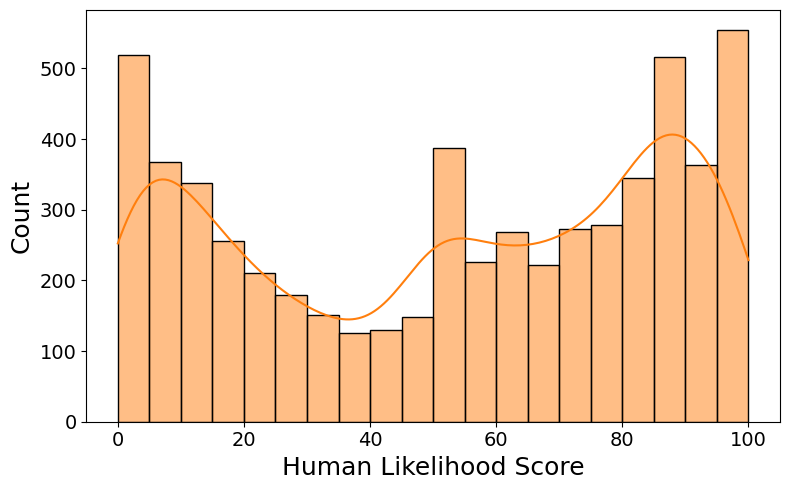

In [12]:

fig,axs = plt.subplots(1,1,figsize=(8,5))
sns.histplot(human_data['response'], bins=list(range(0,101,5)), kde=True, ax=axs, color="#ff7f0e")
axs.set_xlabel("Human Likelihood Score", fontsize=18)
axs.set_ylabel("Count", fontsize=18)
axs.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig("./plots/overall_human_response_distribution.pdf", dpi=300)


## Did slide number (order of stimuli) affect anything?

<Axes: xlabel='slide_number', ylabel='response'>

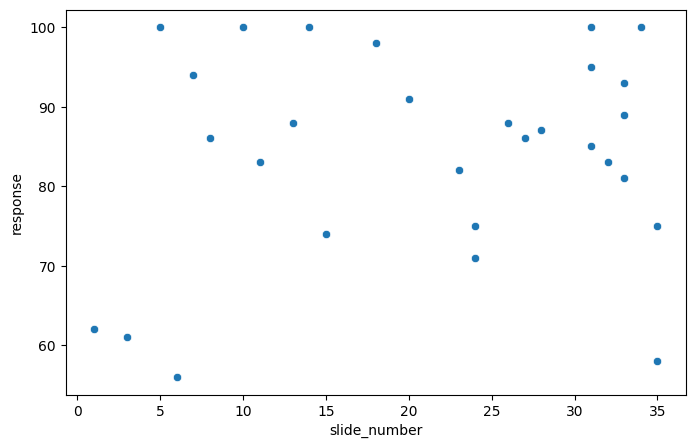

In [14]:
# Look at this relationship for a random datapoint:
random_UID = np.random.choice(human_data['UID'].unique(), size=1)
random_sample = human_data[human_data['UID'].isin(random_UID)]

fig,axs = plt.subplots(1,1,figsize=(8,5))

sns.scatterplot(data=random_sample, x='slide_number', y='response', ax=axs)

In [15]:
slide_number_response_corrs = []
for UID in human_data['UID'].unique():
    sub_data = human_data[human_data['UID'] == UID]
    corr_raw = stats.spearmanr(sub_data['slide_number'], sub_data['response'])
    slide_number_response_corrs.append({'corr_raw': corr_raw[0], 'corr_raw_p_value': corr_raw[1]})

slide_number_response_corrs = pd.DataFrame(slide_number_response_corrs)
slide_number_response_corrs['raw_sig'] = slide_number_response_corrs['corr_raw_p_value'] < 0.05

print(f"Mean Raw Correlation: {slide_number_response_corrs['corr_raw'].mean()}")

print(f"Number of statistically significant correlations: {slide_number_response_corrs['raw_sig'].sum()}/{len(slide_number_response_corrs)}")


Mean Raw Correlation: 0.08275921888793475
Number of statistically significant correlations: 23/210


Note: so there is a statistically significant correlation between stimuli order and human likelihood score response for 23/210 items. But even for these, this correlation won't matter too much, since stimuli order is randomized (i.e., stimuli are randomly shuffled) anyway. 

## Plot: Response Time vs Differential Entropy

SignificanceResult(statistic=np.float64(0.3077085430399065), pvalue=np.float64(6.474764529230277e-06))


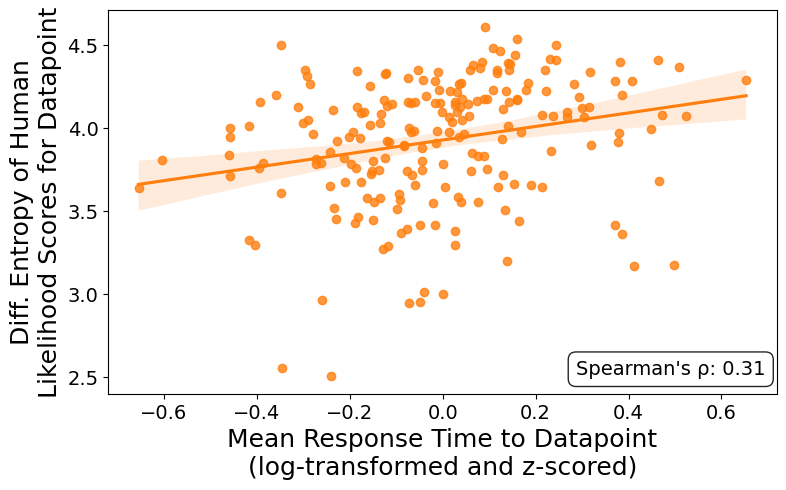

In [22]:
grouped = human_data.groupby(['UID']).agg({'response': 'median', 'marginal_time': 'mean', 'marginal_time_zscored': 'mean', 'marginal_time_log': 'mean', 'marginal_time_log_zscored': 'mean', 'diff_entropy_response': 'mean', 'std_response': 'mean'})
# Remove the one crazy marginal time outlier:
grouped = grouped[grouped['marginal_time'] < 60]


fig,axs = plt.subplots(1,1,figsize=(8,5))

sns.regplot(data=grouped, y='diff_entropy_response', x='marginal_time_log_zscored', ax=axs, color="#ff7f0e")
axs.tick_params(labelsize=14)
axs.set_xlabel("Mean Response Time to Datapoint\n(log-transformed and z-scored)", fontsize=18)
axs.set_ylabel("Diff. Entropy of Human\nLikelihood Scores for Datapoint", fontsize=18)
# Add text showing correlation:
corr = stats.spearmanr(grouped['diff_entropy_response'], grouped['marginal_time_log_zscored'])
axs.text(0.70, 0.05, f"Spearman's ρ: {corr[0]:.2f}", fontsize=14, transform=axs.transAxes, bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
plt.tight_layout()
plt.savefig("./plots/time_vs_entropy.pdf", dpi=300)

print(stats.spearmanr(grouped['diff_entropy_response'], grouped['marginal_time_log_zscored']))



## Bonus Plot: How does response time relate to median human ratings?

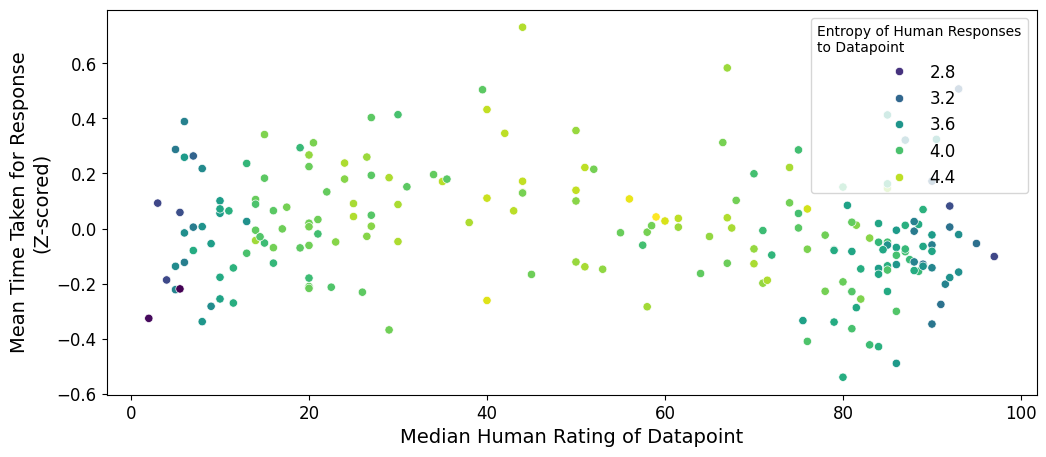

In [23]:
fig,axs = plt.subplots(1,1,figsize=(12,5))
sns.scatterplot(data=grouped, x='response', y='marginal_time_zscored', hue='diff_entropy_response', palette='viridis', ax=axs)

axs.set_xlabel("Median Human Rating of Datapoint", fontsize=14)
axs.set_ylabel("Mean Time Taken for Response\n(Z-scored)", fontsize=14)
axs.legend(title='Entropy of Human Responses\nto Datapoint', fontsize=12)

axs.tick_params(labelsize=12)

Note: hard to tell if anything's going on here -- correlation is mediated by the relationship with differential entropy shown above.

## Plot: Human Response Sample

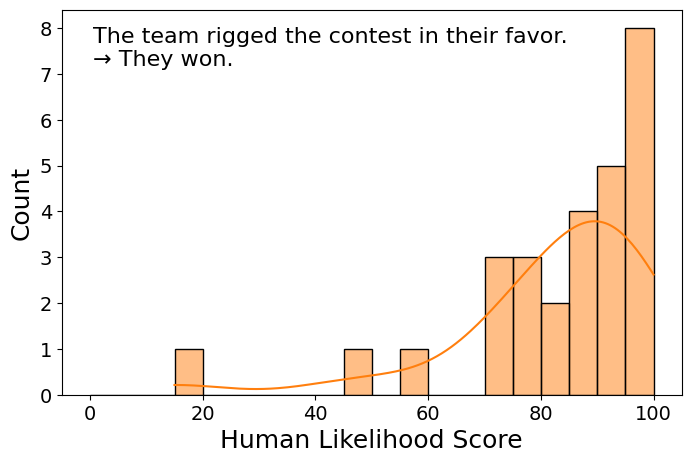

In [24]:
np.random.seed(117)
random_UID_sample = np.random.choice(human_data['UID'].unique(), size=1, replace=False)
UID = random_UID_sample[0]
human_results_sample = human_data[human_data['UID'].isin(random_UID_sample)]

fig,axs = plt.subplots(1,1,figsize=(8, 5))
sub_data = human_results_sample[human_results_sample['UID'] == UID]
premise = sub_data['premise'].unique()[0]
hypothesis = sub_data['hypothesis'].unique()[0]
asks_for = sub_data['asks-for'].unique()[0]
transition = {'cause': 'This was **because**: ', 'effect': 'As a **result**: '}[asks_for]
sns.histplot(sub_data['response'], bins=list(range(0,101,5)), kde=True, ax=axs, color="#ff7f0e")
axs.text(0.05, 0.90, f'{premise}\n→ {hypothesis}', ha='left', va='center', transform=axs.transAxes, fontsize=16)
axs.set_xlabel("Human Likelihood Score", fontsize=18)
axs.set_ylabel("Count", fontsize=18)
# Set tick size:
axs.tick_params(labelsize=14)
plt.savefig("./plots/sample_human_response_distribution.pdf", dpi=300)

## Plot: Median Human Response vs Differential Entropy

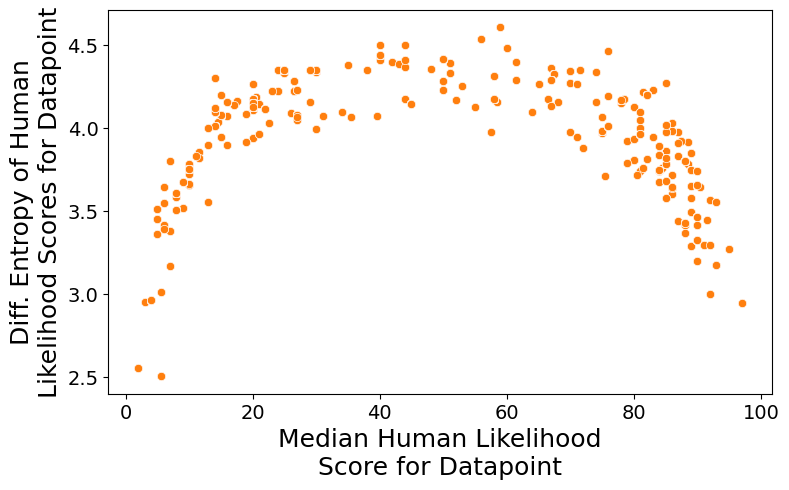

In [25]:
fig,axs = plt.subplots(1,1,figsize=(8,5))
sns.scatterplot(data=human_data, x='median_response', y='diff_entropy_response', ax=axs, color="#ff7f0e")
axs.set_ylabel("Diff. Entropy of Human\nLikelihood Scores for Datapoint", fontsize=18)
axs.set_xlabel("Median Human Likelihood\nScore for Datapoint", fontsize=18)
# Make font larger:
axs.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig("./plots/median_response_vs_entropy.pdf", dpi=300)

## Plot: Joint Plot of Human Results (Figure 2)

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_8348/3053605929.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


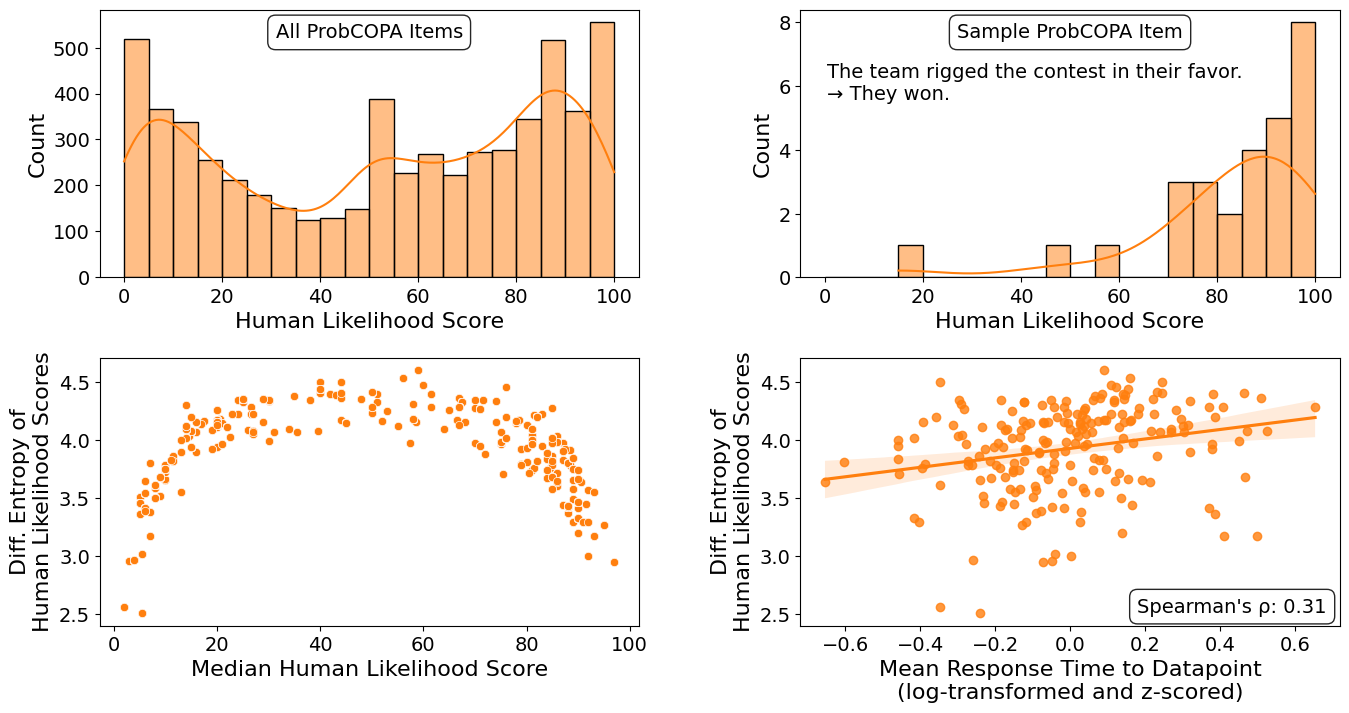

In [26]:
# Create 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(16, 8), 
                        gridspec_kw={'hspace': 0.3, 'wspace': 0.3})



# ============================================================================
# TOP-LEFT: Overall Response Distribution
# ============================================================================
sns.histplot(human_data['response'], bins=list(range(0,101,5)), kde=True, ax=axs[0, 0], color="#ff7f0e")
axs[0, 0].text(0.5, 0.95, 'All ProbCOPA Items', ha='center', va='top', 
               transform=axs[0, 0].transAxes, fontsize=14, 
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
axs[0, 0].set_xlabel("Human Likelihood Score", fontsize=16)
axs[0, 0].set_ylabel("Count", fontsize=16)
axs[0, 0].tick_params(labelsize=14)


# ============================================================================
# TOP-RIGHT: Sample Human Response Distribution
# ============================================================================
np.random.seed(117)
random_UID_sample = np.random.choice(human_data['UID'].unique(), size=1, replace=False)
UID = random_UID_sample[0]
human_results_sample = human_data[human_data['UID'].isin(random_UID_sample)]

sub_data = human_results_sample[human_results_sample['UID'] == UID]
premise = sub_data['premise'].unique()[0]
hypothesis = sub_data['hypothesis'].unique()[0]
asks_for = sub_data['asks-for'].unique()[0]

sns.histplot(sub_data['response'], bins=list(range(0,101,5)), kde=True, ax=axs[0, 1], color="#ff7f0e")
axs[0, 1].text(0.5, 0.95, 'Sample ProbCOPA Item', ha='center', va='top', 
               transform=axs[0, 1].transAxes, fontsize=14, 
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
axs[0, 1].text(0.05, 0.725, f'{premise}\n→ {hypothesis}', ha='left', va='center', 
               transform=axs[0, 1].transAxes, fontsize=14)
axs[0, 1].set_xlabel("Human Likelihood Score", fontsize=16)
axs[0, 1].set_ylabel("Count", fontsize=16)
axs[0, 1].tick_params(labelsize=14)

# ============================================================================
# BOTTOM-LEFT: Median Response vs. Entropy
# ============================================================================
sns.scatterplot(data=human_data, x='median_response', y='diff_entropy_response', ax=axs[1, 0], color="#ff7f0e")
axs[1, 0].set_ylabel("Diff. Entropy of\nHuman Likelihood Scores", fontsize=16)
axs[1, 0].set_xlabel("Median Human Likelihood Score", fontsize=16)
axs[1, 0].tick_params(labelsize=14)

# ============================================================================
# BOTTOM-RIGHT: Time vs. Entropy
# ============================================================================
grouped = human_data.groupby(['UID']).agg({
    'response': 'mean', 
    'marginal_time': 'mean', 
    'marginal_time_zscored': 'mean', 
    'marginal_time_log': 'mean', 
    'marginal_time_log_zscored': 'mean', 
    'diff_entropy_response': 'mean', 
    'std_response': 'mean', 
})
# Remove the one crazy marginal time outlier:
grouped = grouped[grouped['marginal_time'] < 60]

sns.regplot(data=grouped, y='diff_entropy_response', x='marginal_time_log_zscored', ax=axs[1, 1], color="#ff7f0e")
axs[1, 1].tick_params(labelsize=14)
axs[1, 1].set_xlabel("Mean Response Time to Datapoint\n(log-transformed and z-scored)", fontsize=16)
axs[1, 1].set_ylabel("Diff. Entropy of\nHuman Likelihood Scores", fontsize=16)
# Add text showing correlation:
corr = stats.spearmanr(grouped['diff_entropy_response'], grouped['marginal_time_log_zscored'])
axs[1, 1].text(0.625, 0.05, f"Spearman's ρ: {corr[0]:.2f}", fontsize=14, 
               transform=axs[1, 1].transAxes, bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig("./plots/human_joint_four_comparisons.pdf", dpi=300)
plt.show()

## Human Validation Statistical Tests

In [27]:
## Read in the data:

original_full = pd.read_json("results/probcopa_human_results_annotated.jsonl", lines=True)

# The first validation round (used for human baselines):
validation_r1 = pd.read_json("results/probcopa_random_sample_validation_round_human_results_cleaned.jsonl", lines=True)
validation_UIDs = validation_r1['UID'].unique()
original = original_full[original_full['UID'].isin(validation_UIDs)].copy()

# The second validation round (used for prompt validation):
validation_r2 = pd.read_json("results/probcopa_random_sample_prompt_validation_round_human_results_cleaned.jsonl", lines=True)

original['validation_round'] = 'original'
validation_r1['validation_round'] = 'validation'
validation_r2['validation_round'] = 'prompt_validation'

joint_validation = pd.concat([original, validation_r1, validation_r2])


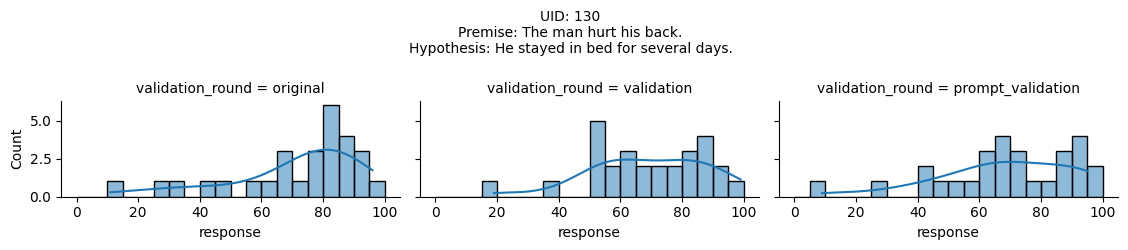

In [28]:
# Visual comparisons:
def inspect_random_sample(UID=None):
    if UID is None:
        UID = np.random.choice(joint_validation['UID'].unique())
    UID_data = joint_validation[joint_validation['UID'] == UID]
    premise = UID_data['premise'].iloc[0]
    hypothesis = UID_data['hypothesis'].iloc[0]
    g = sns.FacetGrid(UID_data, col='validation_round', height=2.5, aspect=1.5, col_wrap=3)
    g.map_dataframe(sns.histplot, x='response', bins=np.arange(0, 101, 5), kde=True)
    plt.suptitle(f"UID: {UID}\nPremise: {premise}\nHypothesis: {hypothesis}", fontsize=10)
    plt.tight_layout()
    plt.show()

inspect_random_sample()

In [32]:
# 2-Sample KS tests:

distributional_results = {}
for UID in tqdm(joint_validation['UID'].unique()):
    UID_data = joint_validation[joint_validation['UID'] == UID]
    original_to_validation_ks_2samp = stats.ks_2samp(UID_data[UID_data['validation_round'] == 'original'].response, UID_data[UID_data['validation_round'] == 'validation'].response)
    original_to_prompt_validation_ks_2samp = stats.ks_2samp(UID_data[UID_data['validation_round'] == 'original'].response, UID_data[UID_data['validation_round'] == 'prompt_validation'].response)
    validation_to_prompt_validation_ks_2samp = stats.ks_2samp(UID_data[UID_data['validation_round'] == 'validation'].response, UID_data[UID_data['validation_round'] == 'prompt_validation'].response)
    distributional_results[UID] = {'original_to_validation_ks_2samp': original_to_validation_ks_2samp.pvalue, 'original_to_prompt_validation_ks_2samp': original_to_prompt_validation_ks_2samp.pvalue, 'validation_to_prompt_validation_ks_2samp': validation_to_prompt_validation_ks_2samp.pvalue}

for UID, results in distributional_results.items():
    print(f"UID: {UID}")
    print(f"KS-test p-value, Original to Validation R1: {results['original_to_validation_ks_2samp']}")
    print(f"KS-test p-value, Original to Prompt Validation R2: {results['original_to_prompt_validation_ks_2samp']}")
    print(f"KS-test p-value, Validation R1 to Prompt Validation R2: {results['validation_to_prompt_validation_ks_2samp']}")
    print("--------------------------------")
    print("\n")


100%|██████████| 30/30 [00:00<00:00, 808.78it/s]

UID: 21
KS-test p-value, Original to Validation R1: 0.7691874860891185
KS-test p-value, Original to Prompt Validation R2: 0.6668042925766526
KS-test p-value, Validation R1 to Prompt Validation R2: 0.9440858097815165
--------------------------------


UID: 208
KS-test p-value, Original to Validation R1: 0.5131310725506154
KS-test p-value, Original to Prompt Validation R2: 0.7793914803845206
KS-test p-value, Validation R1 to Prompt Validation R2: 0.7731666610790539
--------------------------------


UID: 120
KS-test p-value, Original to Validation R1: 0.02920220883960449
KS-test p-value, Original to Prompt Validation R2: 0.23109030242529532
KS-test p-value, Validation R1 to Prompt Validation R2: 0.7731666610790539
--------------------------------


UID: 209
KS-test p-value, Original to Validation R1: 0.36121612966689176
KS-test p-value, Original to Prompt Validation R2: 0.43758595931154615
KS-test p-value, Validation R1 to Prompt Validation R2: 0.9440858097815165
------------------------

In [31]:
# Spearman correlations:

joint_validation.groupby(['UID', 'validation_round']).agg({'response': 'mean'}).reset_index().pivot(index='UID', columns='validation_round', values='response').corr(method='spearman')

validation_round,original,prompt_validation,validation
validation_round,,,
original,1.000000,0.975973,0.974194
prompt_validation,0.975973,1.000000,0.980868
validation,0.974194,0.980868,1.000000


## Plot: Comparison with Pavlick & Kwiatkowski (2019) data (Figure 6)

In [ ]:
## Read in data:

pavlick_data_path = "./datasets/pavlick_kwiatkowski_2019_sentencepair_data.jsonl"
pavlick_data = pd.read_json(pavlick_data_path, lines=True)
pavlick_data =pavlick_data.explode("labels")

probcopa_human_data_path = "./datasets/probcopa.jsonl"
probcopa_human_data = pd.read_json(probcopa_human_data_path, lines=True)

In [34]:
### Relabel entries in the 'task' column:
conversion_dict = {"mnli": "MNLI (Williams et al., 2018)", "snli": "SNLI (Bowman et al., 2015)", "dnc": "DNC (Poliak et al., 2018)", "joci": "JOCI (Zhang et al., 2017)", "rte2": "RTE-2 (Dagan et al., 2006)"}
pavlick_data['task'] = pavlick_data['task'].map(conversion_dict)

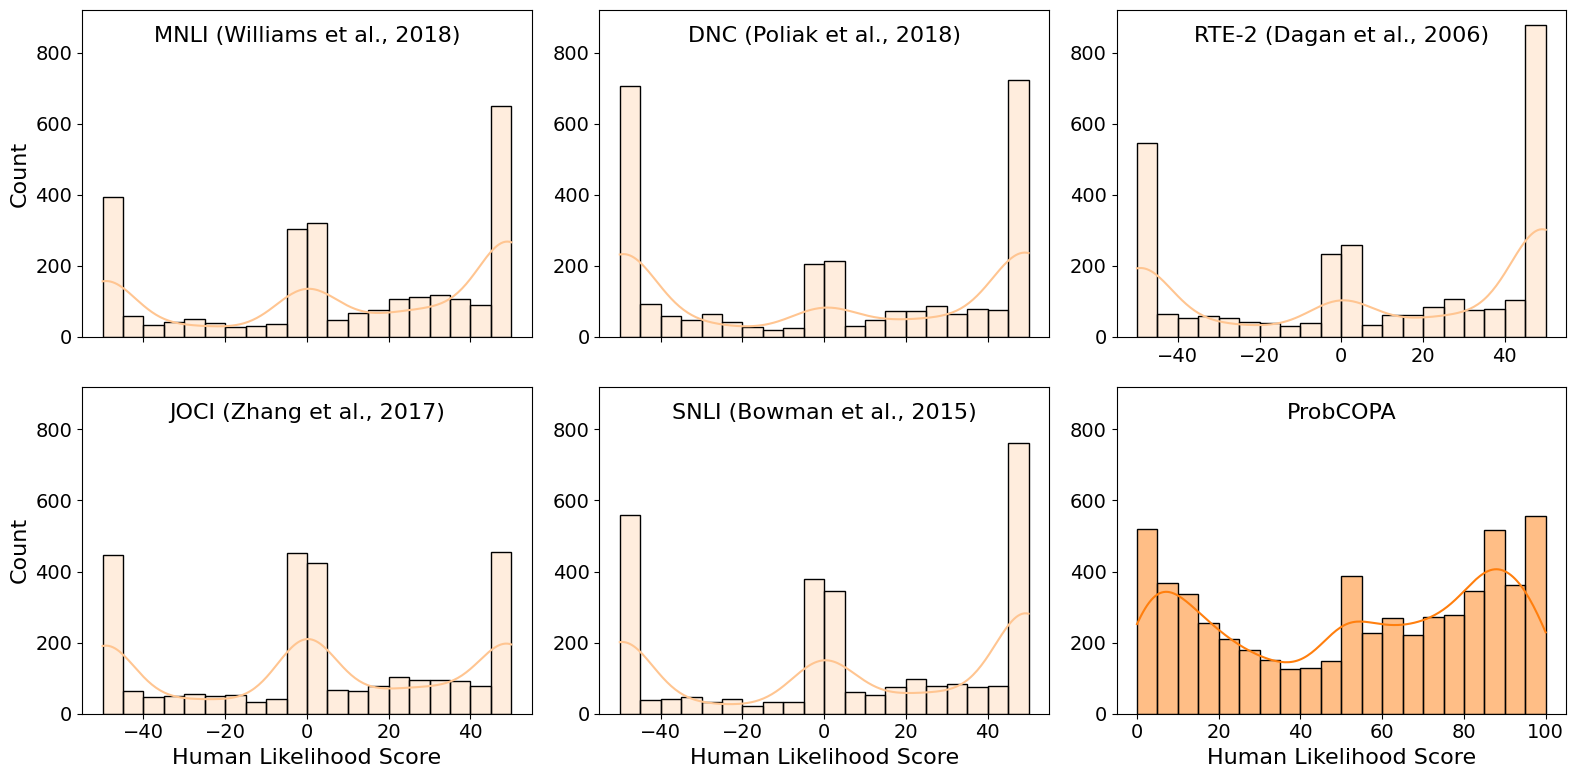

In [36]:
# Font size configuration - adjust these values as needed
FONT_SIZES = {
    'title': 16,        # Facet titles
    'axis_label': 16,   # X and Y axis labels
    'tick_label': 14,   # Tick labels on axes
    'legend': 10        # Legend text (if applicable)
}

# Apply font sizes to matplotlib
plt.rcParams['font.size'] = FONT_SIZES['tick_label']
plt.rcParams['axes.labelsize'] = FONT_SIZES['axis_label']
plt.rcParams['axes.titlesize'] = FONT_SIZES['title']
plt.rcParams['legend.fontsize'] = FONT_SIZES['legend']

# Create a 2x3 subplot layout
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
axs = axs.flatten()  # Flatten to make indexing easier

# Plot first 5 panels: Pavlick data by task
tasks = pavlick_data['task'].unique()
for idx, task_name in enumerate(tasks):
    ax = axs[idx]
    task_data = pavlick_data[pavlick_data['task'] == task_name]['labels']
    
    # Create histogram with KDE
    sns.histplot(task_data, bins=list(range(-50, 51, 5)), kde=True, ax=ax, color="#ffc591", alpha=0.3)
    
    # Add padding to y-axis to prevent text overlap with bars
    ax.set_ylim(0,800)
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 1.15)  # Add 15% padding at top
    
    # Set axis labels - only add x-axis label for bottom row (idx >= 3)
    if idx >= 3:
        ax.set_xlabel("Human Likelihood Score", fontsize=FONT_SIZES['axis_label'])
    else:
        ax.set_xlabel("")
    
    # Only add y-axis label for leftmost column (idx % 3 == 0)
    if idx % 3 == 0:
        ax.set_ylabel("Count", fontsize=FONT_SIZES['axis_label'])
    else:
        ax.set_ylabel("")
    
    # Adjust tick label sizes
    ax.tick_params(labelsize=FONT_SIZES['tick_label'])
    
    # Remove x-axis tick labels for subplots (0,0) and (0,1)
    if idx in [0, 1]:
        ax.tick_params(labelbottom=False)
    
    # Add title inside subplot at top center
    ax.text(0.5, 0.95, task_name, 
            transform=ax.transAxes,
            fontsize=FONT_SIZES['title'],
            ha='center',
            va='top',
            #fontweight='bold'
            )

# Plot 6th panel: ProbCOPA data
ax = axs[5]
sns.histplot(probcopa_human_data['response'], bins=np.arange(0,101,5), kde=True, ax=ax, color="#ff7f0e")

# Add padding to y-axis to prevent text overlap with bars
ax.set_ylim(0,800)
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], ylim[1] * 1.15)  # Add 15% padding at top

# Set axis labels (bottom row, so include x-axis label; rightmost column, so no y-axis label)
ax.set_xlabel("Human Likelihood Score", fontsize=FONT_SIZES['axis_label'])
ax.set_ylabel("")  # Not leftmost column, so no y-axis label

# Adjust tick label sizes
ax.tick_params(labelsize=FONT_SIZES['tick_label'])

# Add title inside subplot at top center
ax.text(0.5, 0.95, "ProbCOPA", 
        transform=ax.transAxes,
        fontsize=FONT_SIZES['title'],
        ha='center',
        va='top',
        #fontweight='bold'
        )

plt.tight_layout()

plt.savefig("./plots/pavlick_data_histograms.pdf", dpi=300)

plt.show()